# End-to-End Pipeline: LAZ to Building Footprints

This pipeline seamlessly takes raw `.laz` / `.ply` files and extracts perfectly orthogonal building footprints as an output `.shp` file using a combination of **RandLA-Net** (Semantic Segmentation) and **Seed-Refine-Snap** (CNN Footprint Extraction).

In [1]:
# ==========================================
# CUSTOM PATH CONFIGURATION
# Set your absolute base directory here.
# For publication/others, this can be f"{BASE_DIR}/"
# ==========================================
import os
BASE_DIR = "/mnt/d/Saqib/Footprint_Extraction/DIF/Code"

# ── Configuration ────────────────────────────────────────────────────
# 1. Input Data
INPUT_LAZ_FILE  ="/mnt/d/Saqib/Footprint_Extraction/laz_obj files/Footprint Extraction Laz Files/66FN2_11"

# INPUT_LAZ_FILE  = f"{BASE_DIR}/data/input.laz"
TILED_DIR       = f"{BASE_DIR}/data/tiled_test/"
TILE_SIZE       = 50.0
OUTPUT_SHP_FILE = f"{BASE_DIR}/outputs/footprints.shp"
BUILDING_CLASS_ID = 1   # 1 = 'Building' after reclassing AHN3
RANDLA_CKPT_PATH  = f"{BASE_DIR}/checkpoints/randlanet_best.pth"
# ── Dataset (must match training) ─────────────────────────────────────
NUM_CLASSES        = 2
IGNORED_LABEL_INDS = []       # training notebook uses [] — no ignored labels
REMAP_CLASSES = {
    0: [0, 1, 2, 3, 4, 5, 7, 9, 26],  # Other
    1: [6],                              # Building
}
LABEL_TO_NAMES = {
    0: 'other',
    1: 'building',
}
CLASS_WEIGHTS = [1_000_000, 1]   # same as training
# ── PLY field names (must match training) ────────────────────────────
POINT_FIELD  = "positions"
LABEL_FIELD  = "class"
FEAT_FIELDS  = []
NUM_NEIGHBORS      = 32
NUM_LAYERS         = 5
NUM_POINTS         = 16384
SUB_SAMPLING_RATIO = [4, 4, 4, 4, 2]
IN_CHANNELS        = 3
DIM_FEATURES       = 8
DIM_OUTPUT         = [16, 64, 128, 256, 512]
GRID_SIZE          = 0.2
WEIGHT_DECAY       = 0.001
AUGMENT = {
    'recenter': {'dim': [0, 1, 2]},
    'rotate': {'method': 'vertical'},
    'scale': {'min_s': 0.9, 'max_s': 1.1},
    'noise': {'noise_std': 0.001}
}
GRID_SIZE_READ  = 0.1
LAZ_CHUNK_SIZE  = 5_000_000
CACHE_DIR       = f"{BASE_DIR}/cache"
USE_CACHE       = True
TEST_BATCH_SIZE = 16
NUM_WORKERS     = 0
PIN_MEMORY      = True
# 3. Footprint CNN Config (GeoRefineNet / BoundaryRefineCNN)
FOOTPRINT_CKPT_PATH = f"{BASE_DIR}/checkpoints/georefinenet.pth"
FOOTPRINT_STATS_PKL = f"{BASE_DIR}/checkpoints/georefinenet_stats.pkl"
# Dataset type for geometry config ("AHN" or "VAIHINGEN")
DATASET_TYPE = "AHN"
# DBSCAN clustering parameters
DBSCAN_EPS        = 1.5
DBSCAN_MIN_POINTS = 50
# Ground Z estimation config
GROUND_BUFFER_M    = 3.0   # XY buffer around footprint to search for ground pts
GROUND_CLASS_ID    = 0     # class index for 'other/ground' (non-building)
GROUND_PERCENTILE  = 5     # use 5th percentile of nearby ground Z as base_z
AUGMENT = {
    'recenter': {'dim': [0, 1, 2]},
    'rotate': {'method': 'vertical'},
    'scale': {'min_s': 0.9, 'max_s': 1.1},
    'noise': {'noise_std': 0.001}
}


In [2]:
# ── Imports & Setup ──────────────────────────────────────────────────
import os, gc, pickle, warnings, time
warnings.filterwarnings('ignore')
import numpy as np
import open3d.ml.torch as ml3d
import torch
import geopandas as gpd
from tqdm.notebook import tqdm
# Import from randla_universal — same module as training notebook
from randla_universal import (
    UniversalPointCloudDataset,
    run_test,
    tile_laz,
    get_memory_usage,
)
# Import from footprint_inference — FIXED module
from footprint_inference import (
    cluster_buildings,
    extract_single_footprint,
    BoundaryRefineCNN,
    load_norm_stats,
    DATASET_CFGS,
    NUM_FEATURES,
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[DEVICE] CUDA: {torch.cuda.is_available()}  |  Device: {device}')
if torch.cuda.is_available():
    print(f'[DEVICE] GPU: {torch.cuda.get_device_name(0)}')
print(f'[MEMORY] Process RAM: {get_memory_usage()}')

# ── MultiPolygon guard (used in Steps 3, 4, 6) ──────────────────────────────
from shapely.geometry import MultiPolygon as _MP

def ensure_polygon(geom):
    """Return the largest-area Polygon from a Polygon or MultiPolygon.
    Returns None if geom is None or empty."""
    if geom is None or geom.is_empty:
        return None
    if isinstance(geom, _MP):
        geom = max(geom.geoms, key=lambda g: g.area)
    return geom


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[DEVICE] CUDA: True  |  Device: cuda
[DEVICE] GPU: NVIDIA RTX 4000 Ada Generation
[MEMORY] Process RAM: 1.9 GB


In [3]:
# ── Step 1: Tile (if needed), Build Dataset & Model, Run Inference ───
# 1a. Tile if the directory is empty
if not os.path.exists(TILED_DIR) or len(os.listdir(TILED_DIR)) == 0:
    print(f'[TILING] Tiling {INPUT_LAZ_FILE} -> {TILED_DIR}')
    tile_laz(INPUT_LAZ_FILE, TILED_DIR, tile_size=TILE_SIZE)
else:
    print(f'[TILING] Already tiled: {TILED_DIR} contains {len(os.listdir(TILED_DIR))} tiles.')
# 1b. Build dataset — identical to training notebook Cell 3
print('\n[DATASET] Building UniversalPointCloudDataset ...')
print(f'[DATASET]   use_cache={USE_CACHE}, grid_size_read={GRID_SIZE_READ}')
t0 = time.time()
dataset = UniversalPointCloudDataset(
    train_files        = TILED_DIR,
    val_files          = TILED_DIR,
    test_files         = TILED_DIR,
    num_classes        = NUM_CLASSES,
    ignored_label_inds = IGNORED_LABEL_INDS,
    label_to_names     = LABEL_TO_NAMES,
    class_weights      = CLASS_WEIGHTS,
    cache_dir          = CACHE_DIR,
    use_cache          = USE_CACHE,
    num_points         = NUM_POINTS,
    point_field        = POINT_FIELD,
    label_field        = LABEL_FIELD,
    feat_fields        = FEAT_FIELDS,
    remap_classes      = REMAP_CLASSES,
    grid_size_read     = GRID_SIZE_READ,
    laz_chunk_size     = LAZ_CHUNK_SIZE,
)
print(f'\n[DATASET] Dataset created in {time.time()-t0:.1f}s')
print(f'[DATASET] Test files: {len(dataset.get_split_list("test"))}')
print(f'[MEMORY]  Process RAM: {get_memory_usage()}')
# 1c. Build model — EXACT same constructor as training notebook Cell 3
print('\n[MODEL] Creating RandLANet ...')
model = ml3d.models.RandLANet(
    name               = 'RandLANet',
    num_neighbors      = NUM_NEIGHBORS,
    num_layers         = NUM_LAYERS,
    num_points         = NUM_POINTS,
    num_classes        = NUM_CLASSES,
    ignored_label_inds = IGNORED_LABEL_INDS,
    sub_sampling_ratio = SUB_SAMPLING_RATIO,
    in_channels        = IN_CHANNELS,
    dim_features       = DIM_FEATURES,
    dim_output         = DIM_OUTPUT,
    grid_size          = GRID_SIZE,
    weight_decay       = WEIGHT_DECAY,
    augment            = AUGMENT,
)
n_params = sum(p.numel() for p in model.parameters())
print(f'[MODEL] Created: {n_params:,} parameters')
gc.collect()
# 1d. Run inference — EXACT same call as training notebook Cell 5
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('\n[INFERENCE] Running Semantic Segmentation ...')
t0 = time.time()
test_metrics, test_results = run_test(
    model           = model,
    dataset         = dataset,
    device          = device,
    ckpt_path       = RANDLA_CKPT_PATH,
    test_batch_size = TEST_BATCH_SIZE,
    num_workers     = NUM_WORKERS,
    pin_memory      = PIN_MEMORY,
)
print(f'\n[INFERENCE] Segmentation complete in {time.time()-t0:.1f}s.')
# 1e. Stitch tile predictions back into one global point cloud
if not test_results:
    raise ValueError('No inference results returned!')
test_split = dataset.get_split('test')
all_pts, all_preds = [], []
for idx, res in enumerate(test_results):
    p  = test_split.get_data(idx)['point']
    pr = res['predict_labels'].flatten()
    all_pts.append(p)
    all_preds.append(pr)
pts         = np.concatenate(all_pts,   axis=0)
predictions = np.concatenate(all_preds, axis=0)
building_count = int((predictions == BUILDING_CLASS_ID).sum())
print(f'[RESULT] Total points : {len(predictions):,}')
print(f'[RESULT] Building pts : {building_count:,}  ({100*building_count/len(predictions):.2f}%)')
print(f'[MEMORY] RAM: {get_memory_usage()}')

[TILING] Already tiled: /mnt/d/Saqib/Footprint_Extraction/DIF/Code/data/tiled_test/ contains 546 tiles.

[DATASET] Building UniversalPointCloudDataset ...
[DATASET]   use_cache=True, grid_size_read=0.1

[DATASET] Dataset created in 0.0s
[DATASET] Test files: 546
[MEMORY]  Process RAM: 1.9 GB

[MODEL] Creating RandLANet ...
[MODEL] Created: 4,994,706 parameters

[INFERENCE] Running Semantic Segmentation ...

──────────────────────────────────────────────────────────────────────
  [TEST] Setting up test pipeline ...
  [TEST] WARNING: no checkpoint loaded — using current model weights
  [TEST] Building test dataloader ...
  [TEST] Dataloader ready (13.9s)  [RAM: 4.0 GB]

  TESTING on 546 tile(s) ...



testing:   0%|          | 0/35 [00:00<?, ?it/s]

  ✓ Completed tile: 66FN2_11_tile_0_0  (39,913 pts)  [RAM: 6.9 GB]
  ✓ Completed tile: 66FN2_11_tile_0_1  (38,366 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_10  (65,468 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_11  (122,654 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_12  (129,680 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_13  (87,130 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_14  (46,113 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_15  (44,774 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_16  (52,689 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_17  (69,664 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_18  (56,973 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_19  (28,629 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_2  (54,685 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_20  (23,645 pts)  [RAM: 7.2 GB]
  ✓ Completed tile: 66FN2_11_tile_0_21  (39,205 p

In [4]:
# ── Step 2: Building Extraction (DBSCAN) ────────────
print(f"Extracting building class {BUILDING_CLASS_ID}...")
# Filter points that were predicted as 'building'
mask = (predictions == BUILDING_CLASS_ID)
building_points = pts[mask]
print(f"Found {len(building_points):,} building points. Clustering with DBSCAN (eps={DBSCAN_EPS}, min_pts={DBSCAN_MIN_POINTS})...")
clusters = cluster_buildings(
    building_points,
    eps=DBSCAN_EPS,
    min_points=DBSCAN_MIN_POINTS,
)
print(f"Successfully isolated {len(clusters)} distinct buildings!")


Extracting building class 1...
Found 841,912 building points. Clustering with DBSCAN (eps=1.5, min_pts=50)...
Successfully isolated 422 distinct buildings!


In [5]:
# ── Step 3: Footprint Extraction (Seed-Refine-Snap) + Ground Z ────────────
print("Loading Footprint CNN (GeoRefineNet)...")
footprint_model = None
stats = None
# Get the geometry config for this dataset type
geometry_cfg = DATASET_CFGS.get(DATASET_TYPE, DATASET_CFGS["AHN"])
print(f"Using {DATASET_TYPE} geometry config (alpha_factor={geometry_cfg['alpha_factor']}, spacing={geometry_cfg['expected_spacing_m']}m)")
if FOOTPRINT_STATS_PKL and os.path.exists(FOOTPRINT_STATS_PKL) and os.path.exists(FOOTPRINT_CKPT_PATH):
    try:
        stats = load_norm_stats(FOOTPRINT_STATS_PKL)
        print(f"  Loaded normalization stats: feat_mean shape={stats['feat_mean'].shape}, targ_mean shape={stats['targ_mean'].shape}")
        footprint_model = BoundaryRefineCNN(in_ch=NUM_FEATURES).to(device)
        ckpt = torch.load(FOOTPRINT_CKPT_PATH, map_location=device)
        footprint_model.load_state_dict(ckpt['model'])
        footprint_model.eval()
        n_params = sum(p.numel() for p in footprint_model.parameters())
        print(f"  Loaded GeoRefineNet: {n_params:,} params | in_ch={NUM_FEATURES} | epoch={ckpt.get('epoch', '?')} | val_loss={ckpt.get('val_loss', float('nan')):.5f}")
    except Exception as e:
        print(f"Warning: Could not load footprint CNN or stats ({e}). Falling back to Seed-Only.")
        footprint_model = None
        stats = None
else:
    missing = []
    if not FOOTPRINT_STATS_PKL or not os.path.exists(FOOTPRINT_STATS_PKL):
        missing.append(f"stats: {FOOTPRINT_STATS_PKL}")
    if not os.path.exists(FOOTPRINT_CKPT_PATH):
        missing.append(f"ckpt: {FOOTPRINT_CKPT_PATH}")
    print(f"Warning: Missing files: {missing}. Falling back to Seed-Only alpha-shape tracing.")

# ── Ground Z estimation helper ────────────────────────────────────────────
from shapely.geometry import box as shapely_box

def estimate_ground_z_near_polygon(all_pts, all_preds, poly,
                                   buffer_m=GROUND_BUFFER_M,
                                   ground_class=GROUND_CLASS_ID,
                                   percentile=GROUND_PERCENTILE):
    """
    Estimate the ground (base) elevation for a building footprint polygon.

    Strategy:
      1. Take all points classified as non-building (ground_class) that fall
         within `buffer_m` metres of the polygon boundary in XY.
      2. Return the `percentile`-th percentile of their Z values as base_z.
         The low percentile guards against vegetation or debris above ground.
      3. Falls back to the minimum Z of all_pts if no ground points are found.
    """
    # Fast axis-aligned pre-filter using the buffered bounding box
    bnd = poly.buffer(buffer_m).bounds          # (minx, miny, maxx, maxy)
    minx, miny, maxx, maxy = bnd

    # Boolean mask: ground class AND inside bounding box
    ground_mask = (all_preds == ground_class)
    bbox_mask   = (
        (all_pts[:, 0] >= minx) & (all_pts[:, 0] <= maxx) &
        (all_pts[:, 1] >= miny) & (all_pts[:, 1] <= maxy)
    )
    candidates  = all_pts[ground_mask & bbox_mask]

    if len(candidates) == 0:
        # No ground points nearby — fall back to global minimum
        return float(np.min(all_pts[:, 2]))

    # Exact XY-distance filter: keep only pts within buffer_m of the polygon
    buffered_poly = poly.buffer(buffer_m)
    from shapely.vectorized import contains
    inside = contains(buffered_poly, candidates[:, 0], candidates[:, 1])
    nearby_z = candidates[inside, 2]

    if len(nearby_z) == 0:
        return float(np.min(all_pts[:, 2]))

    return float(np.percentile(nearby_z, percentile))

# ── Main footprint + base_z extraction loop ─────────────────────────────────
polygons  = []   # Shapely Polygon objects (2-D, XY only)
base_zs   = []   # ground elevation per building
skipped   = 0
print(f"Extracting footprints from {len(clusters)} buildings...")
for i, cluster_pts in enumerate(tqdm(clusters, desc="Buildings")):
    poly = extract_single_footprint(
        cluster_pts,
        footprint_model,
        stats,
        device,
        num_points=150,
        use_postproc=True,
        geometry_cfg=geometry_cfg,
    )
    poly = ensure_polygon(poly)
    if poly is not None and not poly.is_empty:
        # Estimate ground Z using nearby non-building points
        base_z = estimate_ground_z_near_polygon(pts, predictions, poly)
        polygons.append(poly)
        base_zs.append(base_z)
    else:
        skipped += 1
print(f"Extracted {len(polygons)} valid footprints! (skipped {skipped})")


Loading Footprint CNN (GeoRefineNet)...
Using AHN geometry config (alpha_factor=0.82, spacing=0.37m)
Extracting footprints from 422 buildings...


Buildings:   0%|          | 0/422 [00:00<?, ?it/s]

Extracted 422 valid footprints! (skipped 0)


In [6]:
# ── Step 4: Export to Shapefile (.shp) ────────────
from shapely.geometry import Polygon as ShapelyPolygon

def make_3d_polygon(poly_2d, z):
    """Return a Shapely Polygon whose vertices all carry the given Z value."""
    coords_3d = [(x, y, z) for x, y in poly_2d.exterior.coords]
    return ShapelyPolygon(coords_3d)

if len(polygons) == 0:
    print("No footprints to export.")
else:
    print(f"Exporting to {OUTPUT_SHP_FILE}...")
    # Build 3-D versions of each footprint (all vertices at ground level)
    polygons_3d = [make_3d_polygon(ensure_polygon(p), z) for p, z in zip(polygons, base_zs)]

    gdf = gpd.GeoDataFrame({
        "geometry" : polygons,       # 2-D polygon (XY footprint shape)
        "base_z"   : base_zs,        # ground elevation estimate (metres)
        "geom_3d"  : polygons_3d,    # 3-D polygon at ground level (stored as WKT column)
    })
    gdf["geom_3d"] = gdf["geom_3d"].apply(lambda g: g.wkt)   # shapefiles don't natively support 3-D geometry objects in a second column

    # Attempt to assign the exact CRS from the input LAZ file
    if INPUT_LAZ_FILE.lower().endswith('.laz') or INPUT_LAZ_FILE.lower().endswith('.las'):
        import laspy
        with laspy.open(INPUT_LAZ_FILE) as fh:
            if hasattr(fh.header, 'parse_crs') and fh.header.parse_crs():
                gdf.set_crs(fh.header.parse_crs(), inplace=True)
                print("Matched CRS from LAZ header.")

    os.makedirs(os.path.dirname(OUTPUT_SHP_FILE), exist_ok=True)
    gdf.to_file(OUTPUT_SHP_FILE)

    # Summary stats
    print(f"\n[GROUND Z] base_z stats across {len(base_zs)} buildings:")
    print(f"  min={np.min(base_zs):.3f} m  |  median={np.median(base_zs):.3f} m  |  max={np.max(base_zs):.3f} m")
    print("Done! Pipeline finished successfully.")
    print(f"  Columns saved: geometry (2-D footprint), base_z (ground elev m), geom_3d (3-D WKT at base_z)")


Exporting to /mnt/d/Saqib/Footprint_Extraction/DIF/Code/outputs/footprints.shp...

[GROUND Z] base_z stats across 422 buildings:
  min=-2.171 m  |  median=1.188 m  |  max=11.258 m
Done! Pipeline finished successfully.
  Columns saved: geometry (2-D footprint), base_z (ground elev m), geom_3d (3-D WKT at base_z)


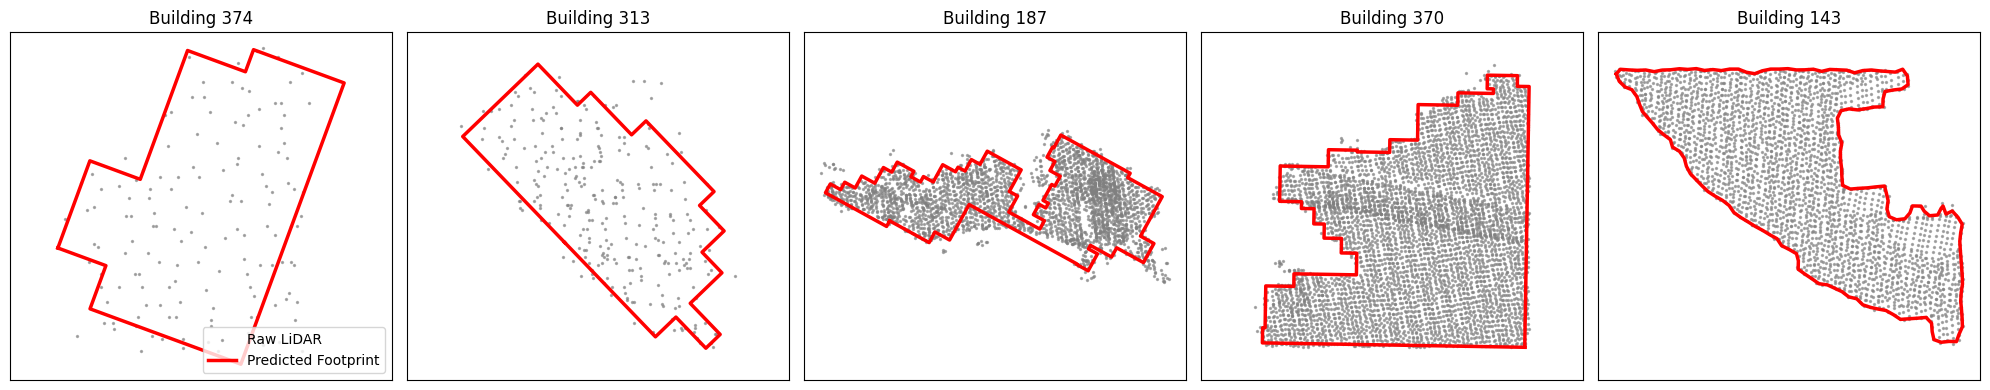

In [7]:
# ── Step 5: Visualize 5 Random Predictions ────────────
import random
import matplotlib.pyplot as plt
import numpy as np
# Pick up to 5 random clusters
num_samples = min(5, len(clusters))
if num_samples == 0:
    print("No buildings found to visualize.")
else:
    sample_indices = random.sample(range(len(clusters)), num_samples)
    fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 4))
    if num_samples == 1:
        axes = [axes]
    for i, idx in enumerate(sample_indices):
        cluster_pts = clusters[idx]
        # We re-extract just these 5 to get their exact matching polygons for the plot
        poly = extract_single_footprint(
            cluster_pts,
            footprint_model,
            stats,
            device,
            num_points=150,
            use_postproc=True,
            geometry_cfg=geometry_cfg,
        )
        ax = axes[i]
        # Plot raw LiDAR points (top-down view)
        ax.scatter(cluster_pts[:, 0], cluster_pts[:, 1], s=2, c='gray', alpha=0.6, label='Raw LiDAR')
        # Plot the predicted polygon boundary
        if poly is not None and not poly.is_empty:
            x, y = poly.exterior.xy
            ax.plot(x, y, color='red', linewidth=2.5, label='Predicted Footprint')
        else:
            ax.set_title(f"Building {idx}\n(Invalid/Skipped)")
        ax.axis('equal')
        ax.set_title(f"Building {idx}")
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


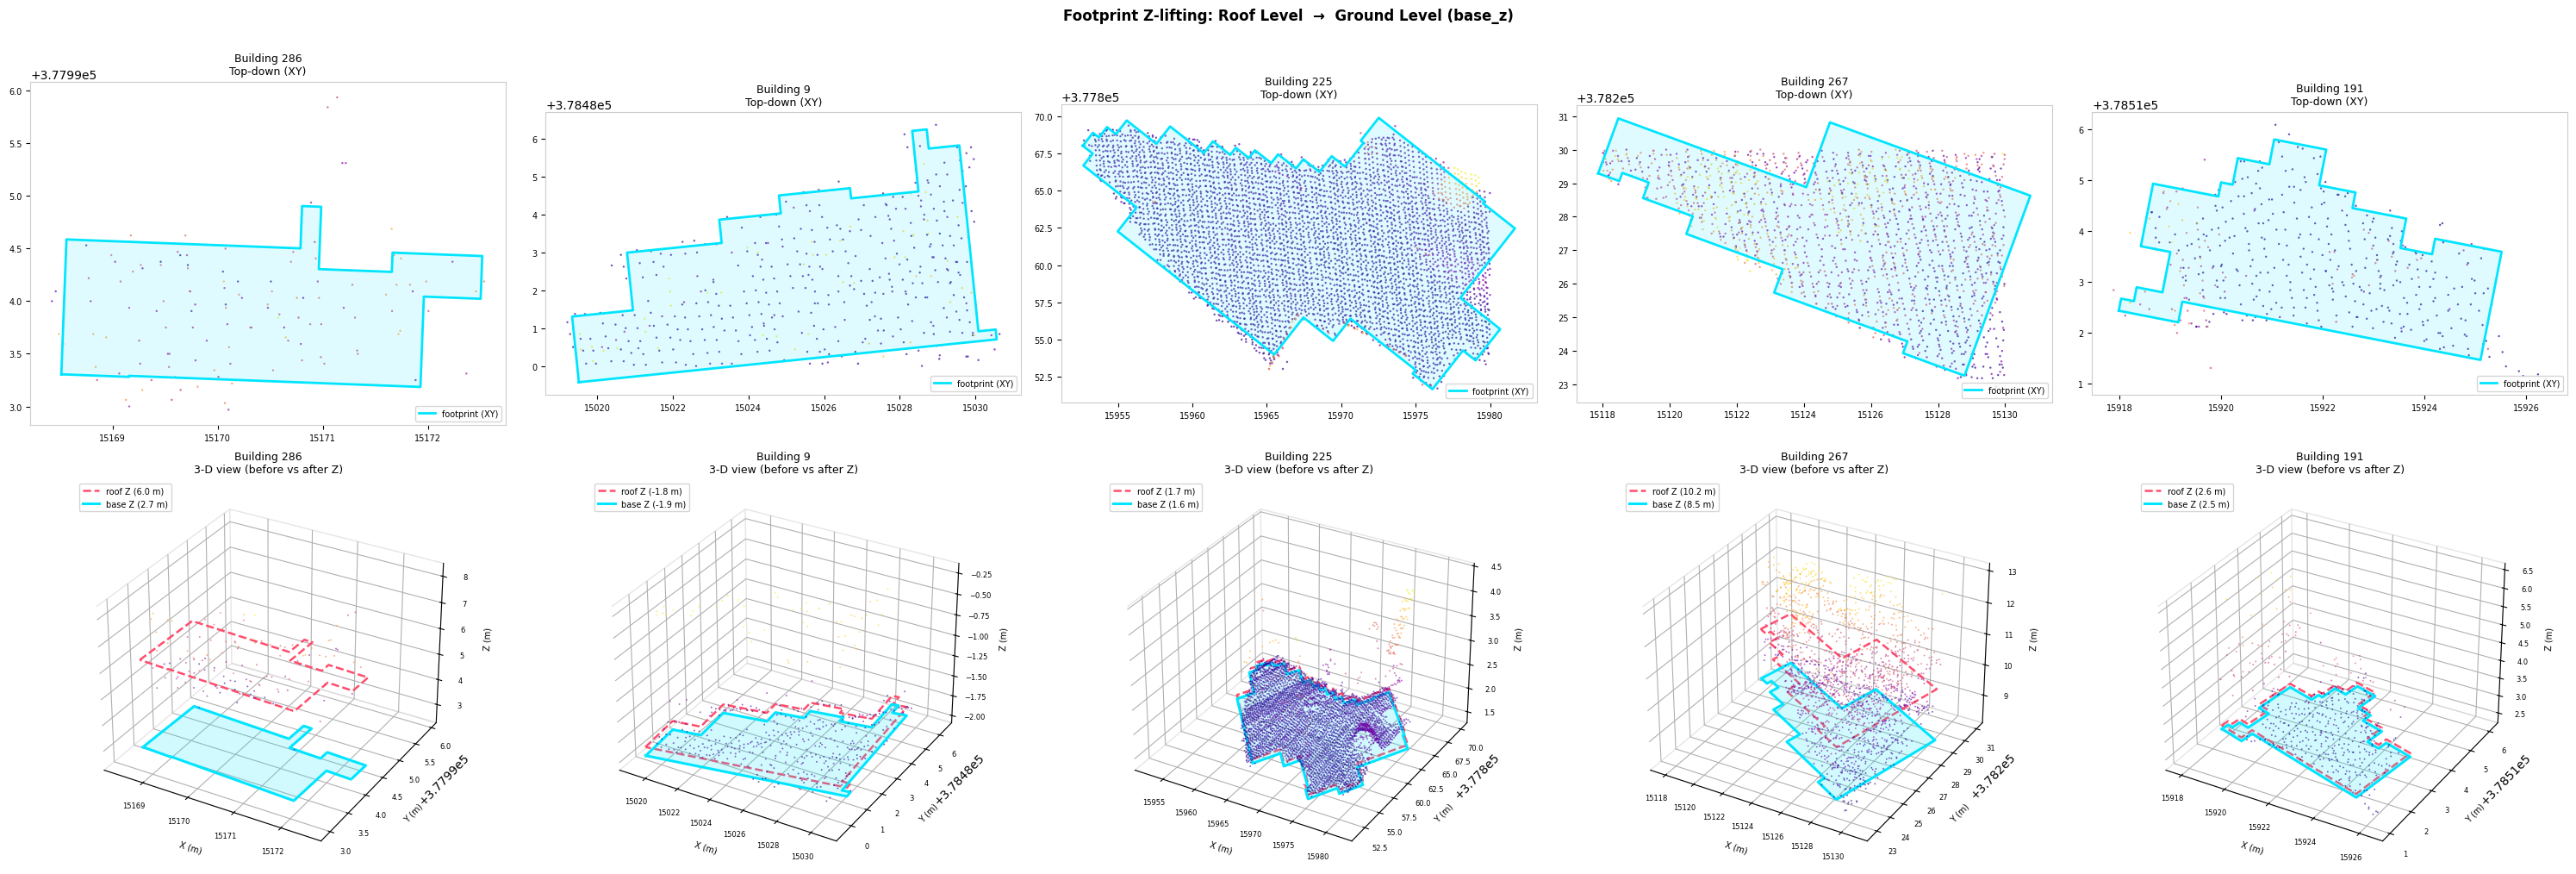

Visualized 5 buildings.  Red dashed = roof Z | Cyan solid = base_z (ground).


In [14]:
# ── Step 6: Visualize Footprint Before vs After Z-lifting ──────────────────────
# Shows up to N_VIZ buildings side-by-side:
#   Left panel  : building LiDAR points (colour = Z) + 2-D footprint at roof Z
#   Right panel : same points in 3-D perspective + both the roof-Z and base-Z rings

import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (needed for projection='3d')
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

N_VIZ = min(5, len(clusters))

if N_VIZ == 0:
    print("No buildings to visualize.")
else:
    sample_indices = random.sample(range(len(clusters)), N_VIZ)
    fig = plt.figure(figsize=(6 * N_VIZ, 10))
    fig.patch.set_facecolor("white")

    for col_idx, bld_idx in enumerate(sample_indices):
        cluster_pts = clusters[bld_idx]
        poly_2d     = ensure_polygon(polygons[bld_idx])
        base_z      = base_zs[bld_idx]

        if poly_2d is None or poly_2d.is_empty:
            continue
        pts_xy = cluster_pts[:, :2]
        pts_z  = cluster_pts[:, 2]
        roof_z = float(np.median(pts_z))          # representative roof elevation

        # Ring coords for 2-D footprint
        ring_x, ring_y = poly_2d.exterior.xy
        ring_x = list(ring_x)
        ring_y = list(ring_y)

        # ── Left panel: top-down 2-D view ─────────────────────────────────
        ax2d = fig.add_subplot(2, N_VIZ, col_idx + 1)
        ax2d.set_facecolor("white")

        norm_z = (pts_z - pts_z.min()) / (pts_z.ptp() + 1e-9)
        colors = cm.plasma(norm_z)
        ax2d.scatter(pts_xy[:, 0], pts_xy[:, 1], c=colors, s=3, alpha=0.7, linewidths=0)

        # Footprint at roof level (2-D projection — shown as outline)
        ax2d.plot(ring_x, ring_y, color="#00e5ff", linewidth=2.0,
                  label=f"footprint (XY)", zorder=5)
        ax2d.fill(ring_x, ring_y, alpha=0.12, color="#00e5ff")

        ax2d.set_title(f"Building {bld_idx}\nTop-down (XY)", color="black", fontsize=9)
        ax2d.tick_params(colors="black", labelsize=7)
        for spine in ax2d.spines.values():
            spine.set_edgecolor("#cccccc")
        ax2d.set_aspect("equal")
        ax2d.legend(fontsize=7, loc="lower right",
                    facecolor="white", edgecolor="#cccccc", labelcolor="black")

        # ── Right panel: 3-D perspective view ─────────────────────────────
        ax3d = fig.add_subplot(2, N_VIZ, N_VIZ + col_idx + 1,
                               projection="3d")
        ax3d.set_facecolor("white")

        # Scatter building points
        ax3d.scatter(pts_xy[:, 0], pts_xy[:, 1], pts_z,
                     c=colors, s=2, alpha=0.6, linewidths=0)

        # Before: footprint ring at roof Z (red dashed = "where points are")
        ax3d.plot(ring_x, ring_y,
                  [roof_z] * len(ring_x),
                  color="#ff4d6d", linewidth=1.8, linestyle="--",
                  label=f"roof Z ({roof_z:.1f} m)")

        # After: footprint ring at base_z (cyan solid = ground-lifted)
        ax3d.plot(ring_x, ring_y,
                  [base_z] * len(ring_x),
                  color="#00e5ff", linewidth=2.2,
                  label=f"base Z ({base_z:.1f} m)")

        # Vertical connectors at corners to show the Z shift
        step = max(1, len(ring_x) // 8)
        for xi, yi in zip(ring_x[::step], ring_y[::step]):
            ax3d.plot([xi, xi], [yi, yi], [base_z, roof_z],
                      color="#ffffff", linewidth=0.6, alpha=0.35, linestyle=":")

        # Shaded base polygon face
        verts = [list(zip(ring_x, ring_y, [base_z] * len(ring_x)))]
        poly_coll = Poly3DCollection(verts, alpha=0.18,
                                     facecolor="#00e5ff", edgecolor="none")
        ax3d.add_collection3d(poly_coll)

        ax3d.set_title(f"Building {bld_idx}\n3-D view (before vs after Z)",
                       color="black", fontsize=9)
        ax3d.tick_params(colors="black", labelsize=6)
        ax3d.xaxis.pane.fill = False
        ax3d.yaxis.pane.fill = False
        ax3d.zaxis.pane.fill = False
        for pane in (ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane):
            pane.set_edgecolor("#cccccc")
        ax3d.set_xlabel("X (m)", color="black", fontsize=7)
        ax3d.set_ylabel("Y (m)", color="black", fontsize=7)
        ax3d.set_zlabel("Z (m)", color="black", fontsize=7)
        ax3d.legend(fontsize=7, loc="upper left",
                    facecolor="white", edgecolor="#cccccc", labelcolor="black")

    fig.suptitle("Footprint Z-lifting: Roof Level  →  Ground Level (base_z)",
                 color="black", fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"Visualized {N_VIZ} buildings.  Red dashed = roof Z | Cyan solid = base_z (ground).")
